# BigBasket Category Performance Diagnostic
## Part 4 — Python / Pandas Cleaning, Analysis & Cross-Validation

This notebook independently cleans and analyzes the raw BigBasket order data and cross-validates the findings from Part 1.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

print("Orders shape:", df.shape)
print("Products shape:", products.shape)

df.info()

Orders shape: (508, 11)
Products shape: (31, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB


In [ ]:
# from the above info, it can be seen that amount_inr and  rating  has null values. The order_date is in object datatype it needs to be changed to datetime datatype.

In [ ]:
df.describe()

,order_id,product_id,quantity,amount_inr,rating
count,508.000000,508.000000,508.000000,498.000000,439.000000
mean,250.204724,15.476378,3.045276,257.530120,3.082005
std,144.594139,8.747467,1.364497,559.424136,1.364126
min,1.000000,1.000000,1.000000,20.000000,1.000000
25%,125.750000,8.000000,2.000000,90.000000,2.000000
50%,249.500000,15.000000,3.000000,168.000000,3.000000
75%,376.250000,23.000000,4.000000,283.750000,4.000000
max,500.000000,30.000000,5.000000,7600.000000,5.000000


In [ ]:
#Rating has an impossible value
#amount_inr has a suspiciously high value


In [4]:
df['status'].value_counts()

,count
status,
Delivered,439
Cancelled,43
Pending,26


In [9]:
# Task 2: Remove duplicate orders

duplicate_count = df.duplicated(subset="order_id").sum()
print("Duplicate order_id rows:", duplicate_count)

Duplicate order_id rows: 8


In [11]:
df = df.drop_duplicates(subset="order_id", keep="first")
df.shape # duplicates have been removed and we came back to 500 rows

(500, 11)

In [14]:
# Task 3: Fix casing and whitespace
VALS=['city','category']
for values in VALS:
  df[values]=df[values].str.strip().str.title()
print("Cities:", sorted(df["city"].unique()))
print("Categories:", sorted(df["category"].unique()))


Cities: ['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']
Categories: ['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']


In [17]:
# Task 4: Inspect missing values

print("Missing amount_inr:", df["amount_inr"].isna().sum())

print("\nMissing rating by status:")

cancelled_missing = df[df["status"] == "Cancelled"]["rating"].isna().sum()
pending_missing = df[df["status"] == "Pending"]["rating"].isna().sum()
delivered_missing = df[df["status"] == "Delivered"]["rating"].isna().sum()

print("Cancelled:", cancelled_missing)
print("Pending:", pending_missing)
print("Delivered:", delivered_missing)

Missing amount_inr: 10

Missing rating by status:
Cancelled: 42
Pending: 24
Delivered: 0


In [18]:
# Task 5: IQR outlier detection and capping

Q1 = df["amount_inr"].quantile(0.25)
Q3 = df["amount_inr"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers = ((df["amount_inr"] < lower_bound) |
            (df["amount_inr"] > upper_bound)).sum()

print("Number of outliers:", outliers)

Q1: 90.0
Q3: 280.0
IQR: 190.0
Lower bound: -195.0
Upper bound: 565.0
Number of outliers: 21


In [19]:
# Cap outliers at the IQR upper bound

df["amount_inr"] = df["amount_inr"].clip(upper=upper_bound)

print("Maximum amount after capping:", df["amount_inr"].max())

Maximum amount after capping: 565.0


In [20]:
# Task 6: Parse dates and create derived columns

df["order_date"] = pd.to_datetime(df["order_date"]) #The order_date is in object datatype it needs to be changed to datetime datatype.

df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name() # We use paranthesis as month_name is a string datatype

df["revenue_per_unit"] = df["amount_inr"] / df["quantity"]

df["is_delivered"] = df["status"] == "Delivered"

print(df[["order_date", "month", "month_name",
          "revenue_per_unit", "is_delivered"]].head())

  order_date  month month_name  revenue_per_unit  is_delivered
0 2026-03-09      3      March              35.0          True
1 2026-05-22      5        May              60.0          True
2 2026-06-30      6       June              75.0          True
3 2026-03-01      3      March              30.0          True
4 2026-04-05      4      April             110.0          True


In [21]:
# Task 7: Inspect products table

print(products.columns)
print(products.head())

Index(['product_id', 'product_name', 'category', 'supplier', 'unit_price_inr'], dtype='object')
   product_id   product_name             category             supplier  \
0           1     Banana 1kg  Fruits & Vegetables        FreshFarms Co   
1           2     Tomato 1kg  Fruits & Vegetables        FreshFarms Co   
2           3      Onion 1kg  Fruits & Vegetables  GreenValley Traders   
3           4      Apple 1kg  Fruits & Vegetables  GreenValley Traders   
4           5  Spinach Bunch  Fruits & Vegetables        FreshFarms Co   

   unit_price_inr  
0              50  
1              40  
2              35  
3             180  
4              25  


In [22]:
# Task 7: Merge orders with products

merged_df = pd.merge(df, products, on="product_id", how="left")

print("Merged shape:", merged_df.shape)
print(merged_df.head())

Merged shape: (500, 19)
   order_id order_date customer_name       city            category_x  \
0         1 2026-03-09           Dev       Pune    Snacks & Beverages   
1         2 2026-05-22         Ayaan  Bengaluru    Snacks & Beverages   
2         3 2026-06-30          Yash  Bengaluru  Household Essentials   
3         4 2026-03-01         Sneha  Hyderabad    Snacks & Beverages   
4         5 2026-04-05         Rohit     Mumbai    Snacks & Beverages   

   product_id  quantity  amount_inr payment_mode     status  rating  month  \
0          13         5       175.0          UPI  Delivered     5.0      3   
1          15         1        60.0   Debit Card  Delivered     5.0      5   
2          25         2       150.0          UPI  Delivered     2.0      6   
3          11         1        30.0          UPI  Delivered     4.0      3   
4          14         2       220.0   Debit Card  Delivered     3.0      4   

  month_name  revenue_per_unit  is_delivered         product_name  \

In [23]:
# Task 7: Total revenue by category

delivered = merged_df[merged_df["status"] == "Delivered"]

category_revenue = delivered.groupby("category_x")["amount_inr"].sum().sort_values(ascending=False)

print("Revenue by category:")
print(category_revenue)

print("\nTop category:", category_revenue.index[0])
print("Top category revenue:", category_revenue.iloc[0])

Revenue by category:
category_x
Household Essentials    20985.0
Bakery                  15000.0
Personal Care           14657.0
Dairy & Eggs            13675.0
Snacks & Beverages      11325.0
Fruits & Vegetables      9195.0
Name: amount_inr, dtype: float64

Top category: Household Essentials
Top category revenue: 20985.0


In [25]:
# Task 7: Total revenue by supplier

supplier_revenue = delivered.groupby("supplier")["amount_inr"].sum().sort_values(ascending=False)

print("Revenue by supplier:")
print(supplier_revenue)

print("\nTop supplier:", supplier_revenue.index[0])
print("Top supplier revenue:", supplier_revenue.iloc[0]) #Gives the value of the first index by position

Revenue by supplier:
supplier
HomeEssentials Traders    20985.0
BakeHouse Supplies        18575.0
CarePlus Distributors     14657.0
DairyBest Ltd             10710.0
SnackHub India             7750.0
FreshFarms Co              5490.0
GreenValley Traders        3705.0
CountryEggs Farms          2965.0
Name: amount_inr, dtype: float64

Top supplier: HomeEssentials Traders
Top supplier revenue: 20985.0


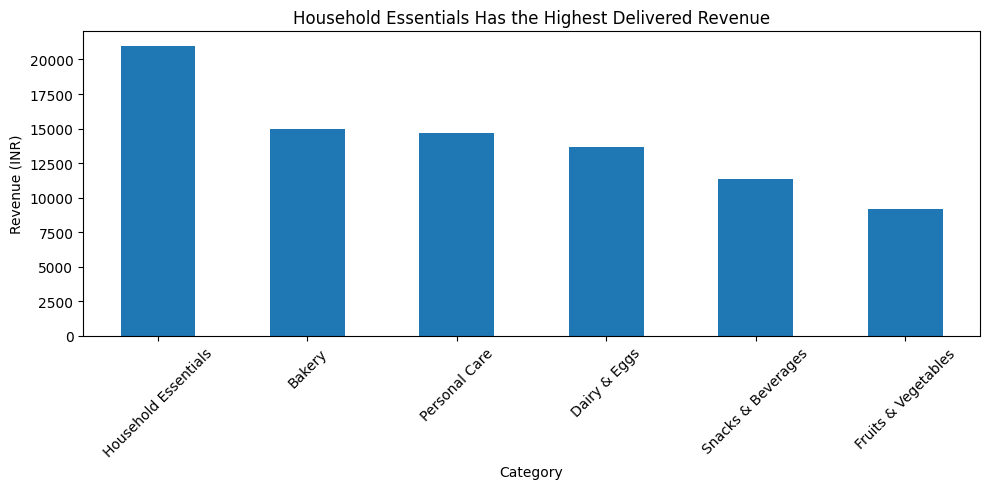

In [26]:
# Task 8: Category revenue chart

plt.figure(figsize=(10, 5))

category_revenue.plot(kind="bar")

plt.title("Household Essentials Has the Highest Delivered Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

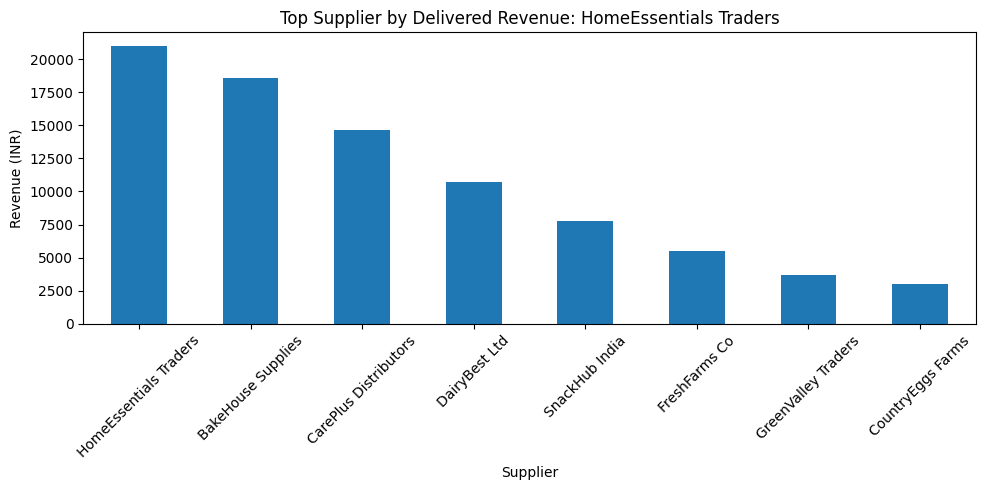

In [27]:
# Task 8: Supplier revenue chart

plt.figure(figsize=(10, 5))

supplier_revenue.plot(kind="bar")

plt.title(f"Top Supplier by Delivered Revenue: {supplier_revenue.index[0]}")
plt.xlabel("Supplier")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
## Key Observations

### 1. What
Household Essentials generated the highest delivered revenue at ₹20,985.

**Why**
It is the strongest-performing category in the cleaned dataset and also matches the top category identified in Part 1.

**Next-step**
Continue monitoring Household Essentials performance and use it as a benchmark for the lower-performing categories.

### 2. What
Snacks & Beverages and Fruits & Vegetables recorded the lowest delivered revenues at ₹11,325 and ₹9,195 respectively.

**Why**
Both categories remain below the stronger-performing categories in the cleaned revenue analysis.

**Next-step**
Prioritize these categories for performance improvement and investigate their product and supplier mix.

### 3. What
The cleaned dataset identifies Household Essentials as the top category, consistent with the Part 1 analysis.

**Why**
The independent Python analysis and the SQL-based category analysis point to the same leading category.

**Next-step**
Use this agreement as a cross-validation check and proceed with the dashboard findings for decision-making.